# Faraji 2021
----
"Tropical Pacific stalagmites are commonly affected by dating uncertainties because of their low
U concentration and/or elevated initial 230Th content."  

Faraji, M., Borsato, A., Frisia, S., Hellstrom, J.C., Lorrey, A., Hartland, A., Greig, A. and Mattey, D.P., 2021. Accurate dating of stalagmites from low seasonal contrast tropical Pacific climate using Sr 2D maps, fabrics and annual hydrological cycles. Scientific Reports, 11(1), p.2178.


# Elevated corections
----
Faraji et al. 2021 used lamina counting chronology to back-calculate the required initial thorium corrections that were needed to align the U-Th ages with laminae ages at the same horizons. 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


# Reported values and uncertainties of the initial thorium back-calcuated from laminae ages
Faraji_val_est = np.array([8.05, 6.00, 5.98, 6.63, 7.74, 6.55, 6.01, 6.21, 6.87, 4.88])
Faraji_err_est = np.array([0.24, 0.25, 0.27, 0.25, 0.18, 0.21, 0.50, 0.46, 0.27, 0.97])

In [6]:
# IBIS example
import ibis 
from ibis import IBIS_Main

# Meta Dictionary with all information - users can tune to their liking here

In [14]:
# Meta Dictionary with all information - users can tune to their liking here

_META = dict(
        # depth handling
        depth_increases_down=True,
        depth_tol=0.0,  # 0 => no rounding

        # boutique sampler
        fraction_det=0.2,
        r02_clip_lo=0.001,
        r02_clip_hi=1000.0,

        # r02 max bound from data (IMPORTANT)
        r02_max_k_sigma=3.0,  # use (r08+kσ)/(r28-kσ)

        # r02 relative uncertainty proposal
        r02_err_mode="halfnorm",   # "fixed"|"uniform"|"halfnorm"
        r02_rel_err=0.25,
        r02_rel_min=0.005,
        r02_rel_max=1.0,

        # validity gates
        age_sigma_gate=3.0,
        age_eps=1e-12,

        # sigma cheating prevention (EB): default False
        use_r02_in_sigma=True,

        # batch sampler controls
        batch_size = 100,
        max_batches=50,
        keep_frac=0.08,
        keep_factor=8,

        # layer windows
        neighbors=1,

        # pair weighting
        pair_weight_mode="exp",   # "none"|"exp"|"power"
        pair_tau_layers=2.0,
        pair_alpha=1.0,
        min_pair_weight=1e-6,

        # prior mixture
        global_mass=0.7,
        n_samples_global=4000,
        n_samples_layer=1000,

        # KDE fit controls
        kde_beta=0.7,
        bw_grid=None,
        cv=5,
        bw_subsample=3000,
        grid_n=1200,
        hi_pct=99.9,
        floor_pdf=1e-12,
    Verbose = True
    )

# Create an IBIS instance 
IBIS requirement minimum
<br>
(1) Pathway to datafile
<br>
(2) Filename
<br>
Extras
<br>
(3) MCMC_samples - how many iterations for the post burn in. 
<br>
(4) MCMC_burn_in - how many samples for burn_in (step adaption only occur in this phase)
<br>
(5) MCMC_Start_samples - define total number of iterations for strat portion (burn-in for this phase is 50% of the total
<br>
(6) n_chains - how many chains to run
<br>
(7) Start_from_pickles - True/False if True will scan folders for last position of chain and restart from that position
<br>
(8) show_bird - True/False if True the bird will print if requirements are satisfied
<br>
(9) method - thoth - this is the method for the determination of the prior distribution
<br>
(10) strat_resolution - model density of the age-depth strat part of the model process
<br>
(11) diction_meta - meta data for model so users can adapt parameters if needed. 

In [11]:

mm = IBIS_Main.IBIS('/Users/johncarter/Detrital Analysis/Desktop/Faraji_2021_data.xlsx',
    sample_name='Faraji_2021_ibis',          
    MCMC_samples=1000000,
    MCMC_burn_in=500000,
    MCMC_Strat_samples=300000,
    n_chains=3,
    Start_from_pickles=True, 
    show_bird=True, 
    method='thoth',
    strat_resolution=100, 
                    diction_meta= _META,
)


Data loaded successfully from /Users/johncarter/Detrital Analysis/Desktop/Faraji_2021_data.xlsx (Excel)
All results will save to: /Users/johncarter/Desktop/Faraji_2021_ibis_folder

                 ==============    ==========     =============   ============
                        =          =         =          =         =
                        =          =          =         =         =
                        =          =          =         =         =
                        =          =         =          =         =
                        =          ==========           =         ============
                        =          =         =          =                    =
                        =          =          =         =                    =
                        =          =          =         =                    =
                        =          =         =          =                    =
                  =============    ==========      ============   =======

In [ ]:
# Part 1 - set up the MCMC

In [12]:
#mm.Get_IBIS_Bounds();

Ages, uncertainties, and maximum age saved to /Users/johncarter/Desktop/Faraji_2021_ibis_folder/Faraji_2021_ibis_bounds.pkl
Bounds and uncertainties computed and saved.


In [16]:
mm.Set_Up_MCMC(); 

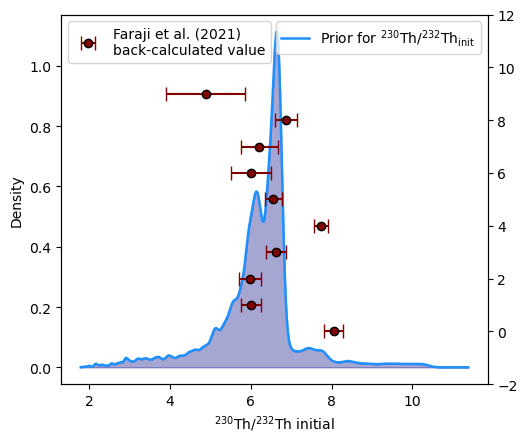

In [28]:
# Plot of the IBIS derived prior using composite 
# global and neighbour estimates
# for comparison "True" are overlain
fig, ax = mm.Plot_Priors()
ax2 =ax.twinx() # Twin x-axis
ax2.errorbar(x = Faraji_val_est, 
             xerr = Faraji_err_est, 
             y = np.arange(Faraji_err_est.size), 
             fmt = 'o', 
             capsize = 5, color = 'maroon', 
            label = 'Faraji et al. (2021)\nback-calculated value', 
            markeredgecolor= 'k')
ax.legend(loc = 'upper right')
ax2.set_ylim(-2, 12)
ax2.legend(loc = 'upper left')

In [29]:
# Run initial thorium
mm.Run_MCMC()

Generating new starting θ’s


Chain 0:  42%|████▏     | 624829/1500000 [01:41<02:28, 5909.58it/s]


[i=5000] acc=0.551  rej(invθ)=0 rej(age_nan)=1 rej(lp_nan)=0 accepted=2757 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.213  U234=0.659  Th230=0.991  Th232=0.999


[i=10000] acc=0.534  rej(invθ)=0 rej(age_nan)=2 rej(lp_nan)=0 accepted=5336 sat_frac=0.000
worst_adj_violation: i=4, j=5, Δ=-6.39467, z=-0.0651134
acc-by-family: Th0=0.212  U234=0.615  Th230=0.986  Th232=0.998


[i=15000] acc=0.521  rej(invθ)=0 rej(age_nan)=4 rej(lp_nan)=0 accepted=7813 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.201  U234=0.601  Th230=0.983  Th232=0.998


[i=20000] acc=0.512  rej(invθ)=0 rej(age_nan)=6 rej(lp_nan)=0 accepted=10240 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.198  U234=0.576  Th230=0.982  Th232=0.997


[i=25000] acc=0.508  rej(invθ)=0 rej(age_nan)=6 rej(lp_nan)=1 accepted=12701 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.203  U234=0.561  Th230=0.977  Th232=0.996


[i=30000] acc=0.505  rej(invθ)=0 rej(age_nan)=7 rej(lp_nan

Chain 0:  68%|██████▊   | 1024388/1500000 [02:51<01:21, 5853.58it/s]


[i=420000] acc=0.415  rej(invθ)=0 rej(age_nan)=103 rej(lp_nan)=5090 accepted=174328 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.242  U234=0.355  Th230=0.733  Th232=0.911


[i=425000] acc=0.414  rej(invθ)=0 rej(age_nan)=105 rej(lp_nan)=5211 accepted=176081 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.242  U234=0.354  Th230=0.730  Th232=0.909


[i=430000] acc=0.413  rej(invθ)=0 rej(age_nan)=107 rej(lp_nan)=5357 accepted=177763 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.242  U234=0.354  Th230=0.727  Th232=0.907


[i=435000] acc=0.412  rej(invθ)=0 rej(age_nan)=109 rej(lp_nan)=5483 accepted=179397 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.242  U234=0.353  Th230=0.724  Th232=0.906


[i=440000] acc=0.412  rej(invθ)=0 rej(age_nan)=109 rej(lp_nan)=5643 accepted=181081 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.242  U234=0.353  Th230=0.721  Th232=0.904


[i=445000] acc=0.411  rej(invθ)=0 rej(age_nan)=11

Chain 0:  96%|█████████▌| 1434795/1500000 [04:02<00:11, 5912.68it/s]


[i=825000] acc=0.367  rej(invθ)=0 rej(age_nan)=244 rej(lp_nan)=16150 accepted=302993 sat_frac=0.000
worst_adj_violation: i=8, j=9, Δ=-6.53709, z=-0.200007
acc-by-family: Th0=0.245  U234=0.318  Th230=0.591  Th232=0.802


[i=830000] acc=0.367  rej(invθ)=0 rej(age_nan)=246 rej(lp_nan)=16287 accepted=304548 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.245  U234=0.318  Th230=0.590  Th232=0.801


[i=835000] acc=0.367  rej(invθ)=0 rej(age_nan)=247 rej(lp_nan)=16423 accepted=306146 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.245  U234=0.318  Th230=0.589  Th232=0.800


[i=840000] acc=0.366  rej(invθ)=0 rej(age_nan)=247 rej(lp_nan)=16555 accepted=307733 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.245  U234=0.318  Th230=0.588  Th232=0.799


[i=845000] acc=0.366  rej(invθ)=0 rej(age_nan)=249 rej(lp_nan)=16689 accepted=309271 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.245  U234=0.318  Th230=0.587  Th232=0.799


[i=850000] acc=

In [32]:
# Save summary to folder
mm.SaveSummary(); 

IBIS summary saved to: /Users/johncarter/Desktop/Faraji_2021_ibis_folder/Faraji_2021_ibis_ibis_summary.csv
Summary saved to Faraji_2021_ibis_ibis_summary.csv


In [33]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
df_summary = pd.read_csv("/Users/johncarter/Desktop/Faraji_2021_ibis_folder/Faraji_2021_ibis_ibis_summary.csv")

In [ ]:
def MonteCarloDelta(x, xerr, y, yerr): 
    n_mc = 10000
    N = np.zeros(len(x), n_mc)
    for i in range(n_mc):

Text(0.5, 0, 'Initial thorium')

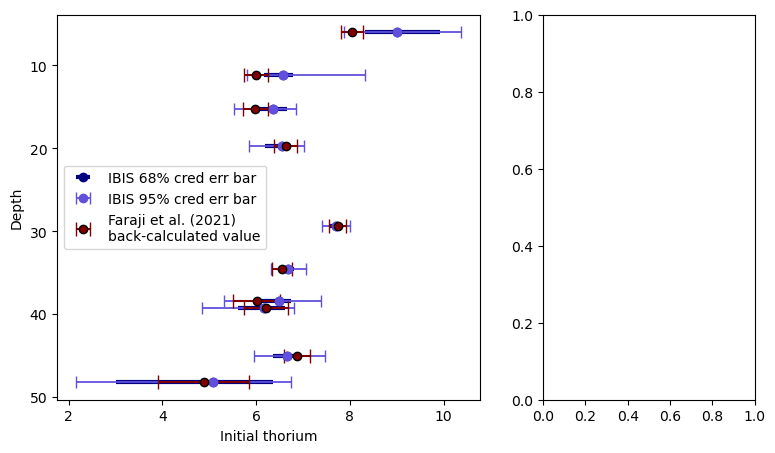

In [42]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2, figsize = (9, 5), 
                     gridspec_kw={"width_ratios": [2, 1]})

ax[0].errorbar(y = df_summary['Depth_Meas'], 
            x = df_summary['initial thorium'],
            xerr = np.vstack([df_summary['Th0_err_lo68'], 
                             df_summary['Th0_err_hi68']]),
              fmt = 'o', lw = 3, 
            color = 'navy',
              label = 'IBIS 68% cred err bar')

ax[0].errorbar(y = df_summary['Depth_Meas'], 
            x = df_summary['initial thorium'],
            xerr = np.vstack([df_summary['Th0_err_lo95'], 
                             df_summary['Th0_err_hi95']]),
              fmt = 'o', lw = 1.3, 
              label = 'IBIS 95% cred err bar', 
           capsize = 4, 
           color = '#6050DC')

ax[0].errorbar(x = Faraji_val_est, 
             xerr = Faraji_err_est, 
             y = df_summary['Depth_Meas'], 
             fmt = 'o', 
             capsize = 5, color = 'maroon', 
            label = 'Faraji et al. (2021)\nback-calculated value', 
            markeredgecolor= 'k')

ax[0].legend()
ax[0].invert_yaxis()
ax[0].set_ylabel('Depth')
ax[0].set_xlabel('Initial thorium')


